<a href="https://colab.research.google.com/github/priyadharshinisuren/CIFAR-10-Classification/blob/main/Copy_of_firstnote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
print("hello")

hello


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#  Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:22<00:00, 7.41MB/s] 


In [ ]:
#  Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)   # input: 3 channels (RGB)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)         # after pooling twice → 8x8
        self.fc2 = nn.Linear(128, 10)                 # 10 CIFAR-10 classes

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)   # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()

In [ ]:
# ✅ Define CNN model class
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:

# ✅ Instantiate model BEFORE optimizer
model = CNNModel()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 1.3411
Epoch 2, Loss: 0.9620
Epoch 3, Loss: 0.8129
Epoch 4, Loss: 0.6969
Epoch 5, Loss: 0.5913


In [ ]:
# Training loop with validation accuracy
for epoch in range(5):
    running_loss = 0.0
    model.train()   # set model to training mode
    for images, labels in trainloader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Compute average training loss
    avg_loss = running_loss / len(trainloader)

    # Validation step
    model.eval()   # set model to evaluation mode
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")


Epoch 1, Loss: 0.5002, Validation Accuracy: 71.94%
Epoch 2, Loss: 0.4108, Validation Accuracy: 71.70%
Epoch 3, Loss: 0.3311, Validation Accuracy: 72.66%
Epoch 4, Loss: 0.2591, Validation Accuracy: 71.97%
Epoch 5, Loss: 0.2044, Validation Accuracy: 70.96%


In [ ]:
class RNNModel(nn.Module):
    def __init__(self, input_size=96, hidden_size=128, num_layers=2, num_classes=10):
        super(RNNModel, self).__init__()
        # Each row has 32 pixels × 3 channels = 96 features
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # CIFAR-10 image: [batch, 3, 32, 32]
        # Rearrange so each row is a timestep
        x = x.permute(0, 2, 3, 1)          # → [batch, 32, 32, 3]
        x = x.reshape(x.size(0), 32, 96)   # → [batch, seq_len=32, input_size=96]

        out, hidden = self.rnn(x)          # RNN expects 3D input
        out = self.fc(hidden[-1])          # last hidden state → classification
        return out


model = RNNModel()

In [ ]:
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 9.83%


In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=96, hidden_size=128, num_layers=2, num_classes=10):
        super(LSTMModel, self).__init__()
        # Each row has 32 pixels × 3 channels = 96 features
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # CIFAR-10 image: [batch, 3, 32, 32]
        x = x.permute(0, 2, 3, 1)          # → [batch, 32, 32, 3]
        x = x.reshape(x.size(0), 32, 96)   # → [batch, seq_len=32, input_size=96]

        out, (hidden, cell) = self.lstm(x) # LSTM returns hidden + cell states
        out = self.fc(hidden[-1])          # last hidden state → classification
        return out


In [ ]:
# ✅ Instantiate model BEFORE optimizer
model = LSTMModel()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 1.7335
Epoch 2, Loss: 1.4720
Epoch 3, Loss: 1.3202
Epoch 4, Loss: 1.2081
Epoch 5, Loss: 1.1180


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


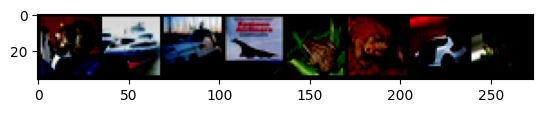

Ground Truth: ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']
Predicted: ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']


In [ ]:
import matplotlib.pyplot as plt
import torchvision

# Show a batch of images
dataiter = iter(testloader)
images, labels = next(dataiter)

# Display images
plt.imshow(torchvision.utils.make_grid(images[:8]).permute(1, 2, 0))
plt.show()

# Predictions
outputs = model(images[:8])
_, predicted = torch.max(outputs, 1)

print("Ground Truth:", [trainset.classes[l] for l in labels[:8]])
print("Predicted:", [trainset.classes[p] for p in predicted[:8]])
